<a href="https://colab.research.google.com/github/Vinay2320/AI-Poultry-Health-Monitoring-System/blob/main/chick_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from collections import Counter
from imblearn.over_sampling import RandomOverSampler  # For oversampling
import albumentations as A
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import resample

In [ ]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print('GPU Available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.15.0
GPU Available: []


In [ ]:
# Define paths
base_path = os.path.join("dataset", "Train")
csv_path = os.path.join("dataset", "train_data.csv")

# Load the CSV file
df = pd.read_csv(csv_path)

# Display basic information about the dataset
print("Dataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check class distribution
print("\nClass Distribution:")
print(df['label'].value_counts())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8067 entries, 0 to 8066
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   images  8067 non-null   object
 1   label   8067 non-null   object
dtypes: object(2)
memory usage: 126.2+ KB
None

First 5 rows:
           images               label
0  salmo.1558.jpg          Salmonella
1  cocci.1866.jpg         Coccidiosis
2   cocci.171.jpg         Coccidiosis
3  salmo.1484.jpg          Salmonella
4     ncd.100.jpg  New Castle Disease

Missing Values:
images    0
label     0
dtype: int64

Class Distribution:
label
Salmonella            2625
Coccidiosis           2476
Healthy               2404
New Castle Disease     562
Name: count, dtype: int64


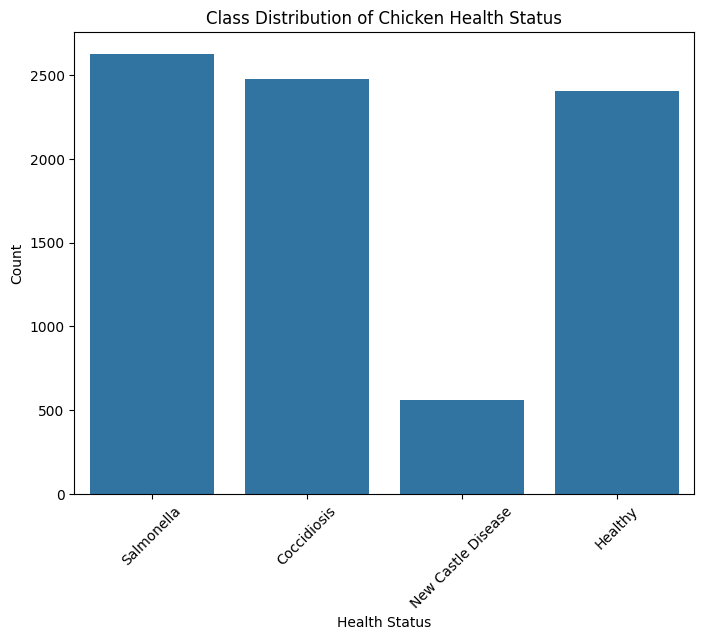

In [ ]:
# Visualize class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=df)
plt.title("Class Distribution of Chicken Health Status")
plt.xlabel("Health Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

All images are accessible and can be loaded.

Image Size Statistics:
        width  height
count  8067.0  8067.0
mean    224.0   224.0
std       0.0     0.0
min     224.0   224.0
25%     224.0   224.0
50%     224.0   224.0
75%     224.0   224.0
max     224.0   224.0


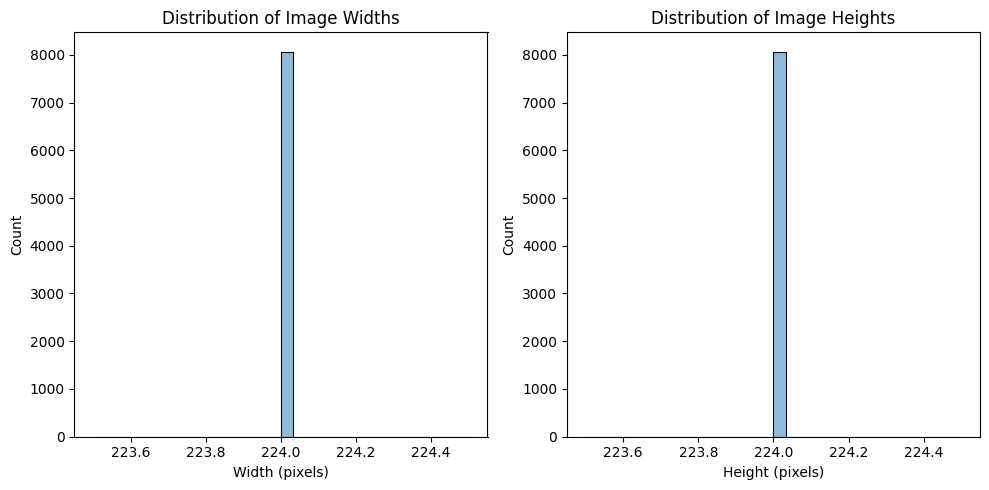

In [ ]:
# Verify that all images exist and can be loaded
missing_images = []
image_sizes = []

for img_name in df['images']:
    img_path = os.path.join(base_path, img_name)
    if not os.path.exists(img_path):
        missing_images.append(img_name)
    else:
        # Load image to check if it can be opened and get its size
        try:
            img = Image.open(img_path)
            image_sizes.append(img.size)  # (width, height)
        except Exception as e:
            missing_images.append(img_name)
            print(f"Error loading {img_name}: {e}")

# Report missing or corrupted images
if missing_images:
    print(f"Found {len(missing_images)} missing or corrupted images:")
    print(missing_images)
else:
    print("All images are accessible and can be loaded.")

# Analyze image sizes
image_sizes_df = pd.DataFrame(image_sizes, columns=['width', 'height'])
print("\nImage Size Statistics:")
print(image_sizes_df.describe())

# Visualize image size distribution
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(image_sizes_df['width'], bins=30, kde=True)
plt.title("Distribution of Image Widths")
plt.xlabel("Width (pixels)")

plt.subplot(1, 2, 2)
sns.histplot(image_sizes_df['height'], bins=30, kde=True)
plt.title("Distribution of Image Heights")
plt.xlabel("Height (pixels)")
plt.tight_layout()
plt.show()

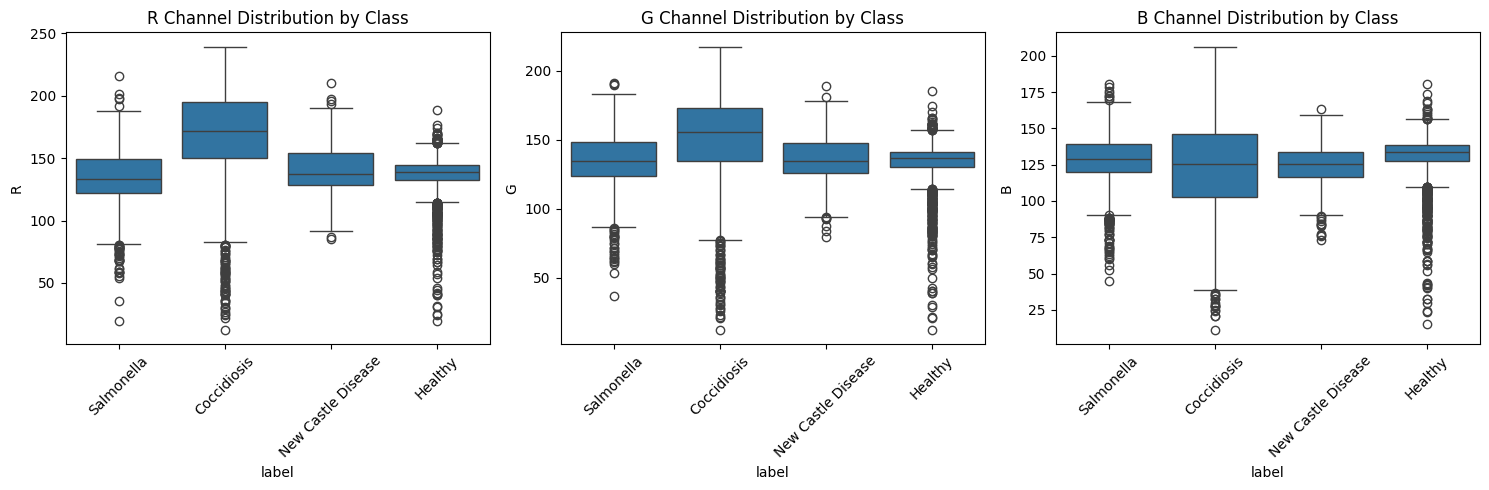

In [ ]:
# Function to compute average RGB values for an image
def get_avg_rgb(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    avg_rgb = img.mean(axis=(0, 1))  # Mean across height and width
    return avg_rgb

# Compute average RGB for each image
rgb_values = []
labels = []

for _, row in df.iterrows():
    img_path = os.path.join(base_path, row['images'])
    try:
        avg_rgb = get_avg_rgb(img_path)
        rgb_values.append(avg_rgb)
        labels.append(row['label'])
    except Exception as e:
        print(f"Error processing {row['images']}: {e}")

# Create a DataFrame with RGB values
rgb_df = pd.DataFrame(rgb_values, columns=['R', 'G', 'B'])
rgb_df['label'] = labels

# Visualize RGB distribution by class
plt.figure(figsize=(15, 5))
for i, channel in enumerate(['R', 'G', 'B']):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x='label', y=channel, data=rgb_df)
    plt.title(f"{channel} Channel Distribution by Class")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

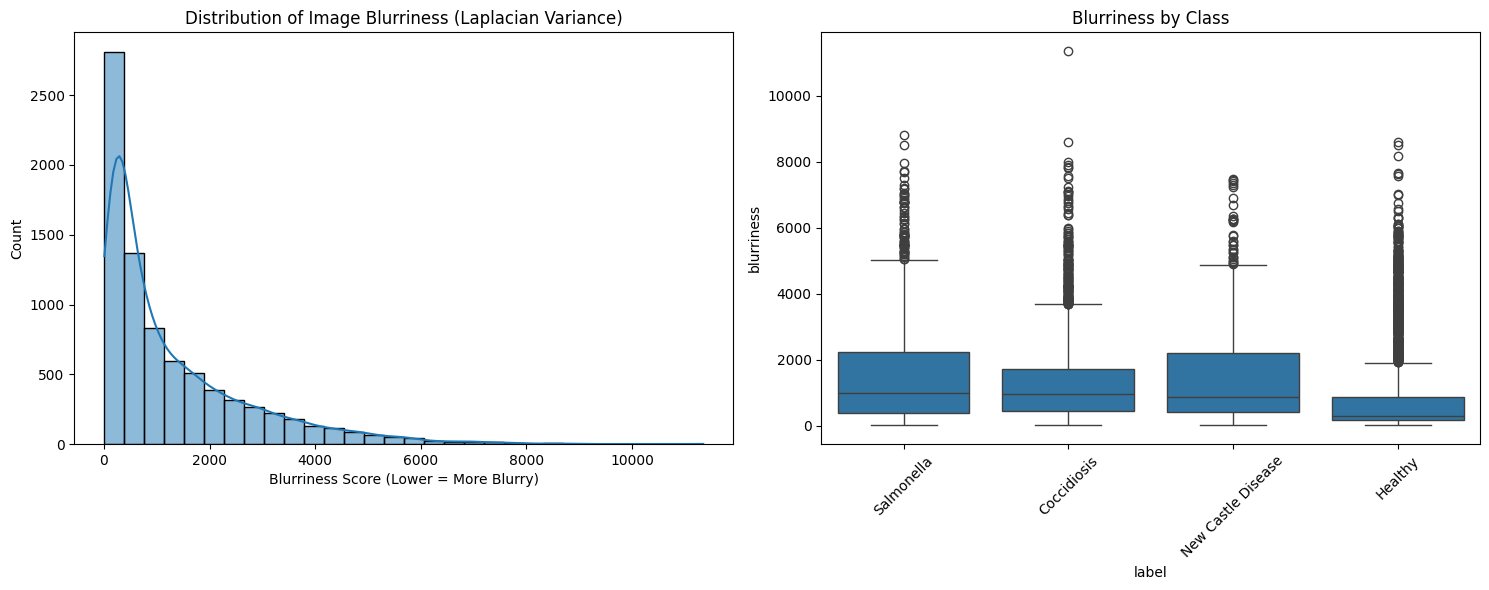

In [ ]:
# Function to compute image blurriness using Laplacian variance
def compute_blurriness(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    laplacian_var = cv2.Laplacian(img, cv2.CV_64F).var()
    return laplacian_var

# Compute blurriness for each image
blurriness = []
for img_name in df['images']:
    img_path = os.path.join(base_path, img_name)
    try:
        blur_score = compute_blurriness(img_path)
        blurriness.append(blur_score)
    except:
        blurriness.append(None)

# Add blurriness to DataFrame
df['blurriness'] = blurriness

# Visualize blurriness distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Blurriness distribution (histogram)
sns.histplot(df['blurriness'].dropna(), bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Image Blurriness (Laplacian Variance)")
axes[0].set_xlabel("Blurriness Score (Lower = More Blurry)")

# Blurriness by class (boxplot)
sns.boxplot(x='label', y='blurriness', data=df, ax=axes[1])
axes[1].set_title("Blurriness by Class")
axes[1].tick_params(axis='x', rotation=45)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

Number of images before filtering: 8067
Number of images after filtering (blurriness >= 500): 4737

Class Distribution After Filtering:
label
Salmonella            1790
Coccidiosis           1776
Healthy                785
New Castle Disease     386
Name: count, dtype: int64


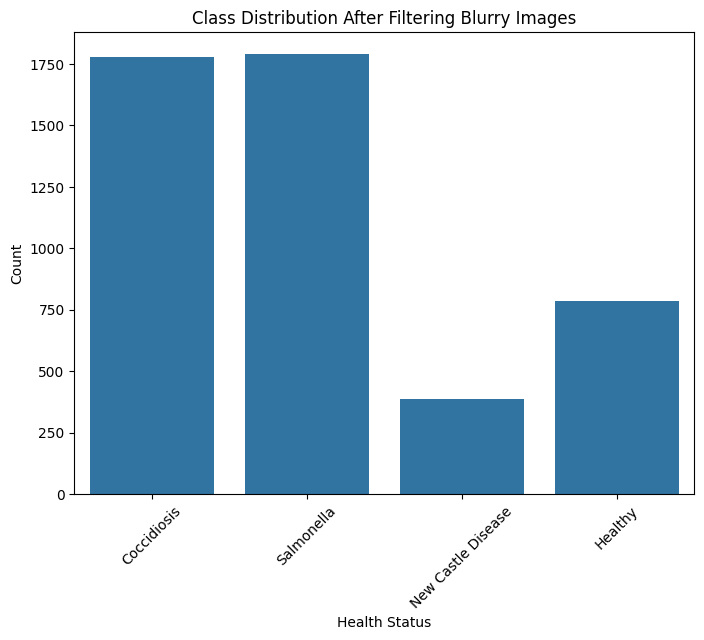

In [ ]:
# Filter out blurry images (Laplacian variance < 500)
blurriness_threshold = 500
print(f"Number of images before filtering: {len(df)}")
df_filtered = df[df['blurriness'] >= blurriness_threshold].copy()
print(f"Number of images after filtering (blurriness >= {blurriness_threshold}): {len(df_filtered)}")

# Check class distribution after filtering
print("\nClass Distribution After Filtering:")
print(df_filtered['label'].value_counts())

# Visualize class distribution after filtering
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=df_filtered)
plt.title("Class Distribution After Filtering Blurry Images")
plt.xlabel("Health Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

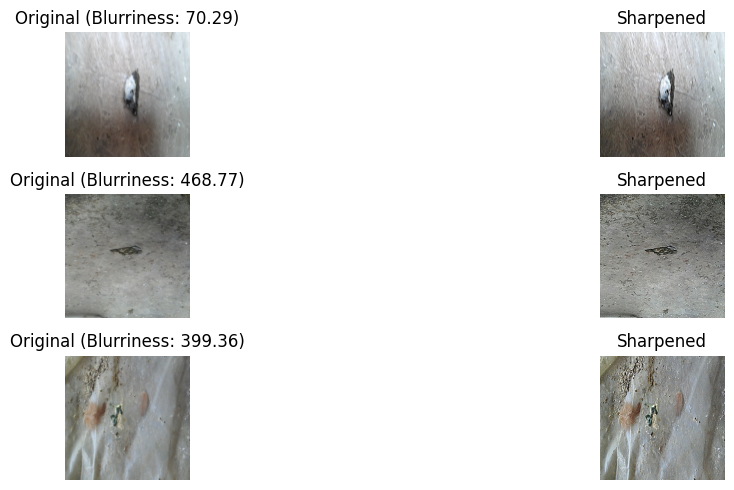

In [ ]:
# Function to sharpen an image
def sharpen_image(img_path):
    img = cv2.imread(img_path)
    # Define a sharpening kernel
    kernel = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]])
    # Apply the sharpening filter
    sharpened = cv2.filter2D(img, -1, kernel)
    return sharpened

# Sharpen a few blurry images and visualize
blurry_images = df[df['blurriness'] < 500].sample(3, random_state=42)
plt.figure(figsize=(15, 5))
for i, (_, row) in enumerate(blurry_images.iterrows()):
    img_path = os.path.join(base_path, row['images'])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    sharpened = sharpen_image(img_path)
    sharpened = cv2.cvtColor(sharpened, cv2.COLOR_BGR2RGB)

    # Original image
    plt.subplot(3, 2, i*2 + 1)
    plt.imshow(img)
    plt.title(f"Original (Blurriness: {row['blurriness']:.2f})")
    plt.axis('off')

    # Sharpened image
    plt.subplot(3, 2, i*2 + 2)
    plt.imshow(sharpened)
    plt.title("Sharpened")
    plt.axis('off')

plt.tight_layout()

Number of images: 4737
Number of labels: 4737
Number of sharpness values: 4737


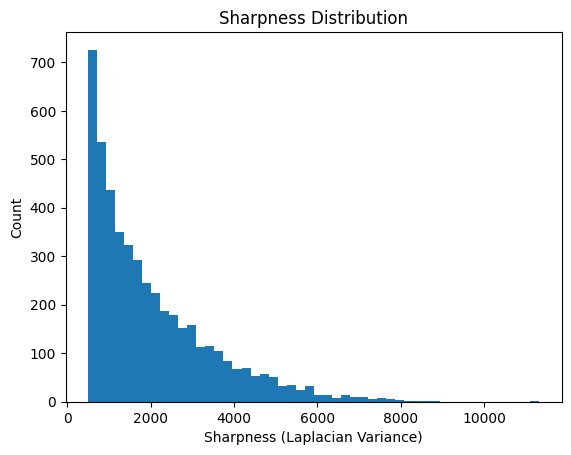

Images with sharpness < 500: 1


In [ ]:
# Load and Preprocess Images
def load_and_preprocess_image(image_path, target_size=(224, 224), sharpness_threshold=500):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not load image at {image_path}")

    # Calculate sharpness (Laplacian variance)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()

    # Sharpen if below threshold
    if sharpness < sharpness_threshold:
        kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
        img = cv2.filter2D(img, -1, kernel)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = img / 255.0  # Normalize
    return img, sharpness

# Prepare images and labels
images = []
labels = []
sharpness_values = []

for idx, row in df_filtered.iterrows():
    img_path = os.path.join(base_path, row['images'])
    try:
        img, sharpness = load_and_preprocess_image(img_path, target_size=(224, 224), sharpness_threshold=500)
        images.append(img)
        labels.append(row['label'])
        sharpness_values.append(sharpness)
    except Exception as e:
        print(f"Error loading image {row['images']} at index {idx}: {e}")
        continue  # Skip the image and label if there's an error

# Convert to NumPy arrays
images = np.array(images, dtype='float32')
labels = np.array(labels)
sharpness_values = np.array(sharpness_values)

# Verify lengths
print(f"Number of images: {len(images)}")
print(f"Number of labels: {len(labels)}")
print(f"Number of sharpness values: {len(sharpness_values)}")

# Check if lengths match
if len(images) != len(labels):
    raise ValueError(f"Mismatch between number of images ({len(images)}) and labels ({len(labels)})")

# Analyze Sharpness and RGB Patterns
plt.hist(sharpness_values, bins=50)
plt.title("Sharpness Distribution")
plt.xlabel("Sharpness (Laplacian Variance)")
plt.ylabel("Count")
plt.show()
print(f"Images with sharpness < 500: {np.sum(sharpness_values < 500)}")

In [ ]:
# Encode labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

# Print mapping
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Mapping:", label_mapping)

# Split the data
from sklearn.model_selection import train_test_split

# Split into train+val and test
X_train_val, X_test, y_train_val, y_test = train_test_split(images, encoded_labels, test_size=0.15, stratify=encoded_labels, random_state=42)

# Split train+val into train and val
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1765, stratify=y_train_val, random_state=42)

print(f"Training set: {len(X_train)} images")
print(f"Validation set: {len(X_val)} images")
print(f"Test set: {len(X_test)} images")

Label Mapping: {'Coccidiosis': 0, 'Healthy': 1, 'New Castle Disease': 2, 'Salmonella': 3}
Training set: 3315 images
Validation set: 711 images
Test set: 711 images


In [ ]:
# Check class distribution in each split
print("Training set class distribution:", np.bincount(y_train))
print("Validation set class distribution:", np.bincount(y_val))
print("Test set class distribution:", np.bincount(y_test))

Training set class distribution: [1243  549  270 1253]
Validation set class distribution: [267 118  58 268]
Test set class distribution: [266 118  58 269]


In [ ]:
# Convert to DataFrame for easier manipulation
train_df = pd.DataFrame({'image': list(X_train), 'label': y_train})

# Separate classes
df_coccidiosis = train_df[train_df['label'] == 0]
df_healthy = train_df[train_df['label'] == 1]
df_new_castle = train_df[train_df['label'] == 2]
df_salmonella = train_df[train_df['label'] == 3]

# Oversample minority classes to match the majority class (1253 samples)
df_healthy_upsampled = resample(df_healthy, replace=True, n_samples=1253, random_state=42)
df_new_castle_upsampled = resample(df_new_castle, replace=True, n_samples=1253, random_state=42)

# Combine back into a single DataFrame
train_df_balanced = pd.concat([df_coccidiosis, df_healthy_upsampled, df_new_castle_upsampled, df_salmonella])
train_df_balanced = train_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Extract X_train and y_train
X_train_balanced = np.array(list(train_df_balanced['image']))
y_train_balanced = train_df_balanced['label'].values

# Verify new class distribution
print("New Training set class distribution:", np.bincount(y_train_balanced))

New Training set class distribution: [1243 1253 1253 1253]


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define augmentation for training data
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# No augmentation for validation/test
val_datagen = ImageDataGenerator()

# Create generators
train_generator = train_datagen.flow(X_train_balanced, y_train_balanced, batch_size=32)
val_generator = val_datagen.flow(X_val, y_val, batch_size=32)

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# Load pre-trained EfficientNetB0 model
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Unfreeze some layers to allow fine-tuning (EfficientNetB0 has fewer layers than ResNet50)
base_model.trainable = True
for layer in base_model.layers[:20]:  # Freeze fewer layers
    layer.trainable = False

# Build the model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])
# Compile the model with a smaller learning rate to fine-tune effectively
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 256)               327936    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dropout_1 (Dropout)         (None, 128)              

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,  # Increased epochs to allow the model to converge
    batch_size=32,
    callbacks=[early_stopping]
)


Epoch 1/30
157/157 [==============================] - 181s 1s/step - loss: 0.5516 - accuracy: 0.8067 - val_loss: 1.5566 - val_accuracy: 0.1716
Epoch 2/30
157/157 [==============================] - 179s 1s/step - loss: 0.2679 - accuracy: 0.9102 - val_loss: 1.5596 - val_accuracy: 0.2574
Epoch 3/30
157/157 [==============================] - 182s 1s/step - loss: 0.2017 - accuracy: 0.9336 - val_loss: 0.7347 - val_accuracy: 0.6878
Epoch 4/30
157/157 [==============================] - 181s 1s/step - loss: 0.1768 - accuracy: 0.9410 - val_loss: 0.4131 - val_accuracy: 0.8622
Epoch 5/30
157/157 [==============================] - 189s 1s/step - loss: 0.1310 - accuracy: 0.9570 - val_loss: 0.2137 - val_accuracy: 0.9339
Epoch 6/30
157/157 [==============================] - 183s 1s/step - loss: 0.1120 - accuracy: 0.9640 - val_loss: 0.1976 - val_accuracy: 0.9226
Epoch 7/30
157/157 [==============================] - 213s 1s/step - loss: 0.0959 - accuracy: 0.9662 - val_loss: 0.1351 - val_accuracy: 0.9480

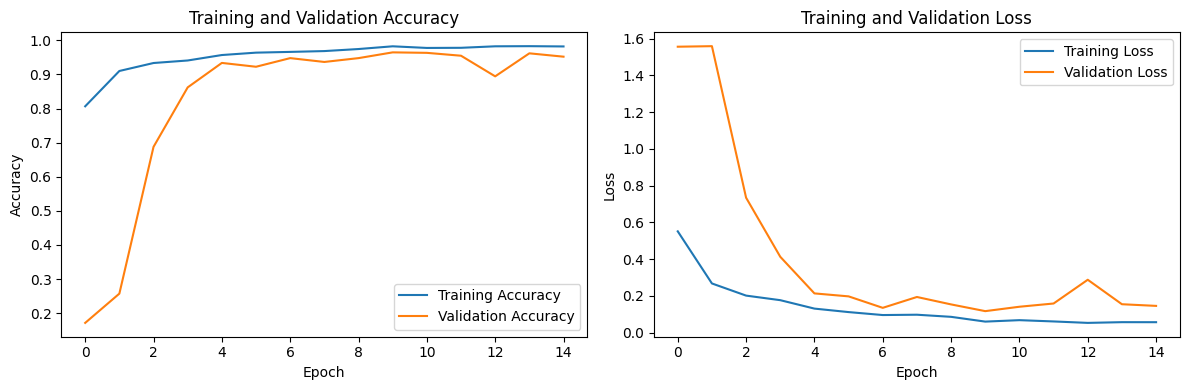

In [ ]:
# Plot training & validation accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Test Loss: 0.1999
Test Accuracy: 0.9409

Classification Report:
                    precision    recall  f1-score   support

       Coccidiosis       0.99      0.95      0.97       266
           Healthy       0.82      0.89      0.85       118
New Castle Disease       0.90      0.95      0.92        58
        Salmonella       0.96      0.96      0.96       269

          accuracy                           0.94       711
         macro avg       0.92      0.94      0.93       711
      weighted avg       0.94      0.94      0.94       711



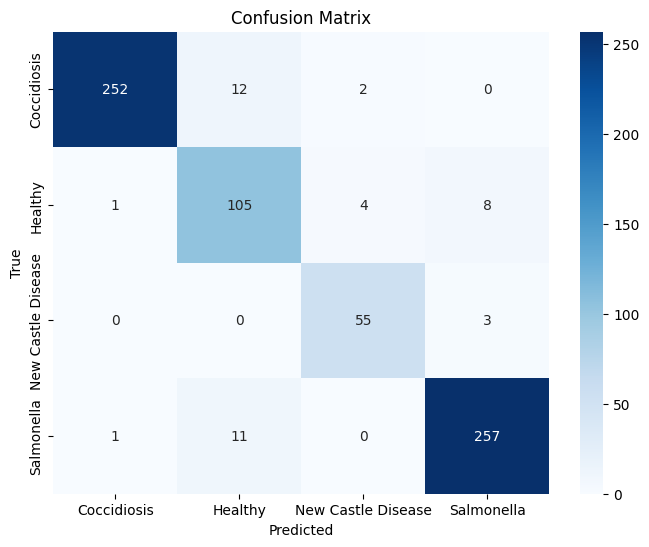

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Classification report
class_names = label_encoder.classes_
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

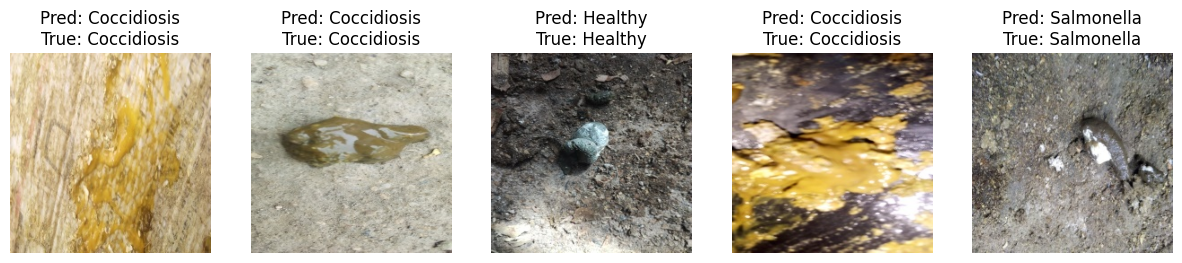

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Test on a few images from the test set
n_samples = 5
indices = np.random.choice(len(X_test), n_samples, replace=False)

plt.figure(figsize=(15, 3))
for i, idx in enumerate(indices):
    # Preprocess the image for prediction
    img = X_test[idx]  # Already normalized
    img_input = np.expand_dims(img, axis=0)

    # Predict
    pred_prob = model.predict(img_input, verbose=0)
    pred_class = np.argmax(pred_prob, axis=1)[0]
    pred_label = label_encoder.inverse_transform([pred_class])[0]
    true_label = label_encoder.inverse_transform([y_test[idx]])[0]

    # Display the image
    img_display = np.clip(img, 0, 1)  # Ensure values are in [0, 1]
    plt.subplot(1, n_samples, i+1)
    plt.imshow(img_display)
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}")
    plt.axis('off')
plt.show()

In [ ]:
# Save the model
try:
    model.save("chicken_disease_model_efficientnetb0_final.h5", save_format='h5')
    print("Model saved successfully.")
except Exception as e:
    print(f"Error saving model: {e}")

# Save the label encoder
import pickle
try:
    with open('label_encoder.pkl', 'wb') as f:
        pickle.dump(label_encoder, f)
    print("Label encoder saved successfully.")
except Exception as e:
    print(f"Error saving label encoder: {e}")

c:\Users\PureGoat\Chicken decease idenify\chick-env-new\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model saved successfully.
Label encoder saved successfully.


Label encoder loaded successfully.
Classes: ['Coccidiosis' 'Healthy' 'New Castle Disease' 'Salmonella']
Model loaded successfully.
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 256)               327936    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               32

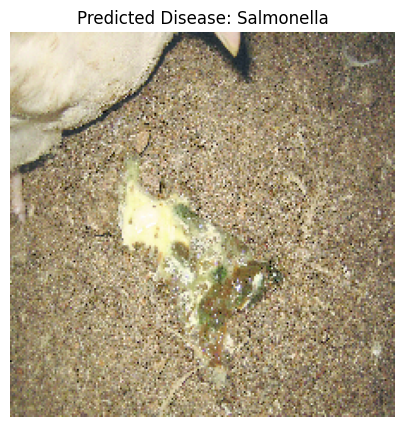

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Load the label encoder
with open('model/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)
print("Label encoder loaded successfully.")
print("Classes:", label_encoder.classes_)

# Load the model
try:
    model = load_model('model/chicken_disease_model_efficientnetb0_final.h5')
    print("Model loaded successfully.")
    model.summary()
except Exception as e:
    print(f"Error loading model: {e}")

# Function to load and preprocess an image
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    img = load_img(image_path, target_size=target_size)
    img = img_to_array(img)
    img = img / 255.0
    return img

# Function to predict disease
def predict_disease(image_path, model, label_encoder, target_size=(224, 224)):
    img = load_and_preprocess_image(image_path, target_size=target_size)
    img = np.expand_dims(img, axis=0)
    prediction = model.predict(img)
    predicted_class_idx = np.argmax(prediction, axis=1)[0]
    predicted_class = label_encoder.inverse_transform([predicted_class_idx])[0]
    return predicted_class

# Test the prediction
new_image_path = "dataset/test_image/Salmonella01.jpg"
# Ensure the image exists
try:
    predicted_disease = predict_disease(new_image_path, model, label_encoder)
    print(f"Predicted Disease: {predicted_disease}")

    # Visualize the image and prediction
    img = load_img(new_image_path, target_size=(224, 224))
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Predicted Disease: {predicted_disease}")
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"Error during prediction: {e}")